In [7]:
import pandas as pd

df = pd.read_excel('../data/coffee_sales.xlsx')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[us]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  str           
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  str           
 9   product_type      149116 non-null  str           
 10  product_detail    149116 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(4), object(1), str(4)
memory usage: 12.5+ MB


In [8]:
df.head()


,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


날짜: transaction_date
시간: transaction_time
수량: transaction_qty
가격: unit_price
상품: product_type, product_detail
위치: store_location

1. 매출 컬럼

In [9]:
df['sales'] = df['transaction_qty'] * df['unit_price']
cols = ['sales'] + [col for col in df.columns if col != 'sales']
df = df[cols]
df.head()

,sales,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,6.0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,6.2,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,9.0,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,2.0,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,6.2,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


2. 시간 컬럼

In [10]:
df['hour'] = df['transaction_time'].apply(lambda x: x.hour)
cols = ['hour'] + [col for col in df.columns if col != 'hour']
df = df[cols]
df.head()

,hour,sales,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,7,6.0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,7,6.2,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,7,9.0,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,7,2.0,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,7,6.2,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


3. 시간대별 매출

In [11]:
# 'hour'의 각 값별 개수 확인
df['hour'].value_counts()

hour
10    18545
9     17764
8     17654
7     13428
11     9766
16     9093
15     8979
14     8933
17     8745
13     8714
12     8708
18     7498
19     6092
6      4594
20      603
Name: count, dtype: int64

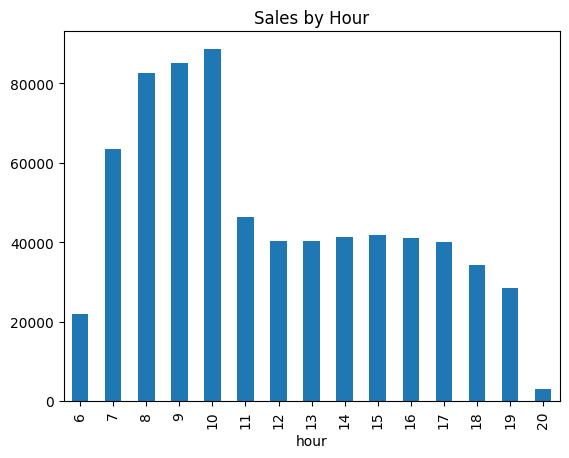

In [12]:
hourly_sales = df.groupby('hour')['sales'].sum()

import matplotlib.pyplot as plt

hourly_sales.plot(kind='bar')
plt.title('Sales by Hour')
plt.show()

4. 요일별 매출

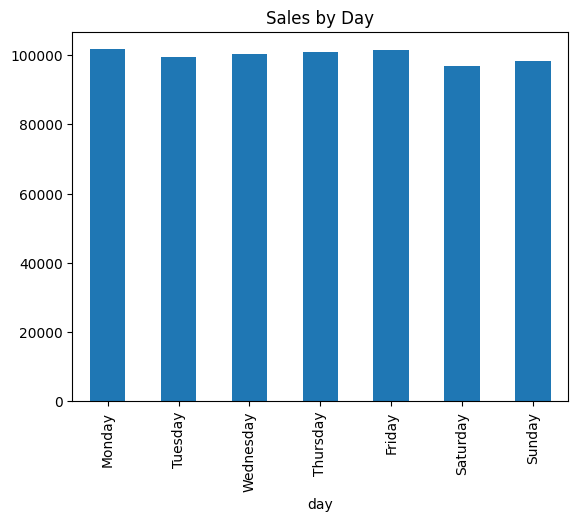

In [14]:
df['day'] = df['transaction_date'].dt.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_sales = df.groupby('day')['sales'].sum().reindex(day_order)

day_sales.plot(kind='bar')
plt.title('Sales by Day')
plt.show()

5. 인기 메뉴 TOP10

1) product_category 기준

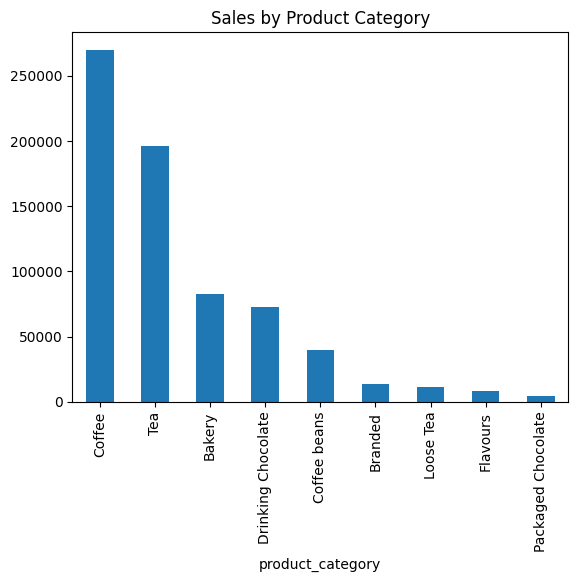

In [15]:
top_products_c = df.groupby('product_category')['sales'].sum().sort_values(ascending=False).head(10)

top_products_c.plot(kind='bar')
plt.title('Sales by Product Category')
plt.show()

2) product_type 기준

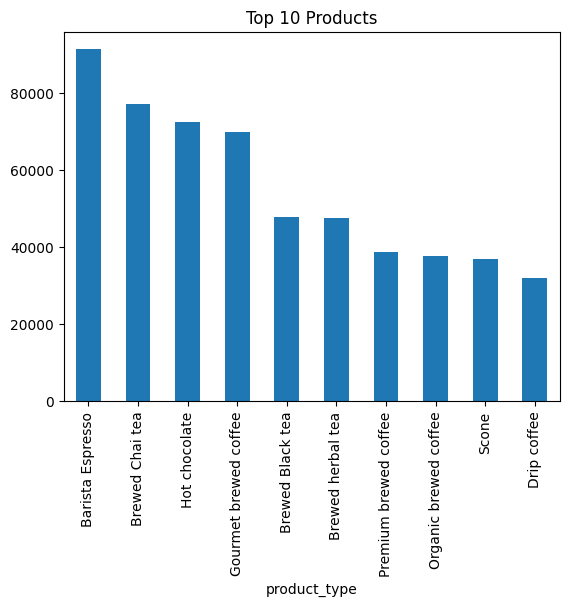

In [ ]:
top_products = df.groupby('product_type')['sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')
plt.title('Top 10 Products')
plt.show()